# Visualization

In [2]:
from Config.config import CONFIG
CONFIG = CONFIG("LinkPred")

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

shap_event_df = pd.read_csv(f"Results/{CONFIG.data.dataset_name}/Shapley4TGNNEvent.csv")
shap_feature_df = pd.read_csv(f"Results/{CONFIG.data.dataset_name}/Shapley4TGNNFeature.csv")
tgnn_df = pd.read_csv(f"Results/{CONFIG.data.dataset_name}/TGNNExplainer.csv")
tempme_df = pd.read_csv(f"Results/{CONFIG.data.dataset_name}/TempME.csv")

shap_event_df['Explainer'] = 'Shapley4TGNNEvent'
shap_feature_df['Explainer'] = 'Shapley4TGNNFeature'
tgnn_df['Explainer'] = 'TGNNExplainer'
tempme_df['Explainer'] = 'TempME'

results_df = pd.concat([shap_event_df, shap_feature_df, tgnn_df, tempme_df], axis=0)
results_df.head()

,Original prediction,Ground truth,y,Sparsity thresholds,Fidelity to prediction,Fidelity to prediction (logit),Deviation to ground truth,Accuracy,Source,Destination,Timestamp,Instance index,Remove technique,Explainer
0,0.867765,1.0,0.917191,0.000000,-0.049427,0.523447,-0.082809,1.0,30,8232,86148.75,0,Mean,Shapley4TGNNEvent
1,0.867765,1.0,0.917191,0.000911,-0.049427,0.523447,-0.082809,1.0,30,8232,86148.75,0,Mean,Shapley4TGNNEvent
2,0.867765,1.0,0.917191,0.001212,-0.049427,0.523447,-0.082809,1.0,30,8232,86148.75,0,Mean,Shapley4TGNNEvent
3,0.867765,1.0,0.917191,0.001612,-0.049427,0.523447,-0.082809,1.0,30,8232,86148.75,0,Mean,Shapley4TGNNEvent
4,0.867765,1.0,0.917191,0.002144,-0.049427,0.523447,-0.082809,1.0,30,8232,86148.75,0,Mean,Shapley4TGNNEvent


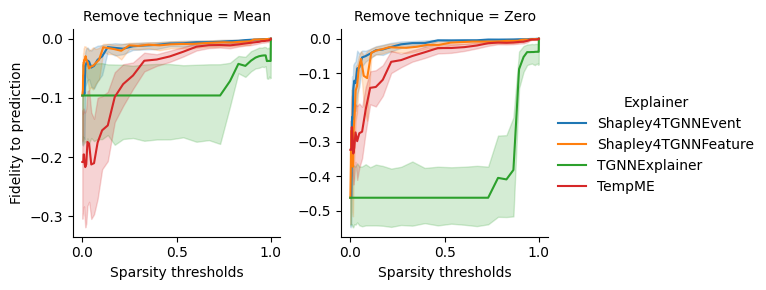

In [40]:
df = results_df.copy()

g = sns.FacetGrid(df, col="Remove technique", hue="Explainer", sharey=False, sharex=False)
g.map(sns.lineplot, 'Sparsity thresholds', 'Fidelity to prediction')
#Add legend
g.add_legend()

In [16]:
from sklearn.metrics import auc
from scipy.integrate import trapezoid

# Change these two names when a different curve should be integrated.
x_column = "Sparsity thresholds"
y_column = "Fidelity to prediction"

group_columns = ["Remove technique", "Explainer", "Instance index"]

result = []
for identifiers, group in results_df.groupby(group_columns, dropna=False):
    area = trapezoid(group[y_column], group[x_column])
    technique, explainer, instance = identifiers
    result.append({
        "Explainer": explainer,
        "technique": technique,
        "instance": instance,
        "AUC": area,
    })

auc_df = pd.DataFrame(result, columns=["Explainer", "technique", "instance", "AUC"])
auc_df

,Explainer,technique,instance,AUC
0,Shapley4TGNNEvent,Mean,0,-0.003854
1,Shapley4TGNNEvent,Mean,1,-0.052025
2,Shapley4TGNNEvent,Mean,2,-0.003490
3,Shapley4TGNNEvent,Mean,3,-0.009496
4,Shapley4TGNNEvent,Mean,4,-0.005596
...,...,...,...,...
107,TempME,Zero,10,-0.095562
108,TempME,Zero,11,-0.071492
109,TempME,Zero,12,-0.052836
110,TempME,Zero,13,-0.049436


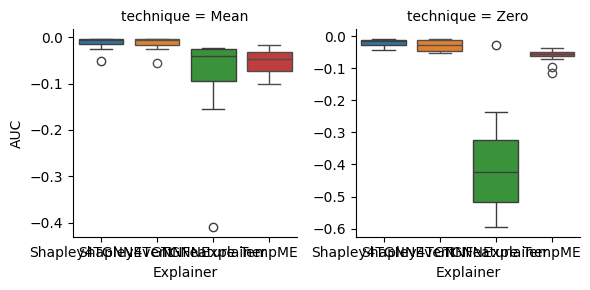

In [20]:
g = sns.FacetGrid(auc_df, col="technique", hue="Explainer", sharey=False, sharex=False)
g.map(sns.boxplot, "Explainer", "AUC", order=["Shapley4TGNNEvent", "Shapley4TGNNFeature", "TGNNExplainer", "TempME"])

In [39]:
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests

shap_event_auc = auc_df[auc_df["Explainer"] == "Shapley4TGNNEvent"]["AUC"].values
shap_feature_auc = auc_df[auc_df["Explainer"] == "Shapley4TGNNFeature"]["AUC"].values
tgnn_auc = auc_df[auc_df["Explainer"] == "TGNNExplainer"]["AUC"].values
tempme_auc = auc_df[auc_df["Explainer"] == "TempME"]["AUC"].values

statistic1, p_value1 = wilcoxon(shap_event_auc, tempme_auc, alternative="greater")
statistic2, p_value2 = wilcoxon(shap_event_auc, tgnn_auc, alternative="greater")

corrected = multipletests([p_value1, p_value2], method='holm')[1]

print(statistic1, p_value1)
print(statistic2, p_value2)

print(corrected)

405.0 7.450580596923828e-09
405.0 7.450580596923828e-09
[1.49011612e-08 1.49011612e-08]


In [37]:
pd.DataFrame({
    "Shap_event_auc": shap_event_auc,
    "Shap_feature_auc": shap_feature_auc,
    "TGNNExplainer_auc": tgnn_auc,
    "TempME_auc": tempme_auc,
    "Shap_smaller_tempMe": shap_event_auc < tempme_auc,
    "Shap_smaller_tgnn": shap_event_auc < tgnn_auc
}).head(20)

,Shap_event_auc,Shap_feature_auc,TGNNExplainer_auc,TempME_auc,Shap_smaller_tempMe,Shap_smaller_tgnn
0,-0.003854,-0.003851,-0.047352,-0.024530,False,False
1,-0.052025,-0.055335,-0.143785,-0.051390,True,False
2,-0.003490,-0.003166,-0.023587,-0.075052,False,False
3,-0.009496,-0.009498,-0.063784,-0.019707,False,False
4,-0.005596,-0.005829,-0.023742,-0.031826,False,False
5,-0.024875,-0.017381,-0.410354,-0.080741,False,False
6,-0.006958,-0.004845,-0.049839,-0.100266,False,False
7,-0.004013,-0.005046,-0.022690,-0.069003,False,False
8,-0.005299,-0.004061,-0.024841,-0.032184,False,False
9,-0.002974,-0.003875,-0.032447,-0.041886,False,False


42    -0.024530
43    -0.051390
44    -0.075052
45    -0.019707
46    -0.031826
47    -0.080741
48    -0.100266
49    -0.069003
50    -0.032184
51    -0.041886
52    -0.074374
53    -0.050677
54    -0.041826
55    -0.017404
98    -0.057532
99    -0.062933
100   -0.062155
101   -0.038262
102   -0.038161
103   -0.052673
104   -0.115421
105   -0.047973
106   -0.046881
107   -0.095562
108   -0.071492
109   -0.052836
110   -0.049436
111   -0.055135
Name: AUC, dtype: float64

In [27]:
statistic1, p_value1 = wilcoxon(shap_event_auc, tgnn_auc, alternative="greater")
print(statistic1, p_value1)

405.0 7.450580596923828e-09
